In [1]:
import time
import math
import os
from collections import namedtuple, defaultdict, Counter
import pathlib
import json

from tqdm.notebook import tqdm
import numpy as np
import pandas as pd

from sdrsdm import TriadicMemory

import sys
sys.path.append('../../lib')

from utils import *

# Setup

In [2]:
LOG = Logging()
RNG = np.random.default_rng(100)

with open(get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
    notebook_fname = json.load(cf)['jupyter_session']
    notebook_fname = os.path.basename(notebook_fname)

print(f'notebook={notebook_fname}')
LOG.app_name = os.path.splitext(notebook_fname)[0].upper()

notebook=temporal_test.ipynb


## SdrSpace

In [3]:
class SdrSpace:
    def __init__(self, n, p):
        self.n = n
        self.p = p

    def get_empty(self):
        return np.array([], dtype=int)

    def get_random(self):
        inds = RNG.choice(self.n, self.p, replace=False)
        inds.sort()
        return inds

    def get_near(self, s, switch=3):
        assert switch >= 0
        switch = min(switch, len(s))

        if switch == 0:
            # nothing to switch
            return s

        if len(s) > switch:
            # keep some bits from original sdr
            preserved_inds = RNG.choice(s, len(s) - switch, replace=False, shuffle=True)
        else:
            # nothing to keep from original sdr
            preserved_inds = np.array([], dtype=int)
            
        repertoir = set(range(self.n))
        
        for ind in s:
            repertoir.remove(ind)

        assert self.p > len(preserved_inds)
        inds = RNG.choice(list(repertoir), self.p - len(preserved_inds), replace=False)
        inds = np.r_[preserved_inds, inds]
        inds.sort()
        return inds

    def expand(self, s):
        r = np.zeros(self.n, dtype='b')

        if len(s) > 0:
            r[s] = 1
            
        return r

    def union(self, s1, s2):
        united = np.r_[s1, s2]
        return np.unique(united)

    def overlap(self, s1, s2):
        s1 = set(s1)
        s2 = set(s2)
        return len(s1 & s2)

    def hdist(self, s1, s2):
        s1 = set(s1)
        s2 = set(s2)
        return len(s1 ^ s2)

    # What is the probability to get two SDR with both having number of shared_bits
    def get_shared_bits_p(self, shared_bits):
        # see sbv_test.ipynb
        max_wrong_picks_count = self.p - shared_bits
        chance_nomin_part1 = math.prod(range(self.p, self.p - shared_bits, -1))
        chances = []
        
        for wrong_picks_count in range(max_wrong_picks_count + 1):
            # compute solo chance of getting a single correct guess by using number of wrong_picks
            l = self.n - self.p
            chance_nomin_part2 = math.prod(range(l, l - wrong_picks_count, -1))
            chance_denom = math.prod(range(self.n, self.n - shared_bits - wrong_picks_count, -1))
            chance = chance_nomin_part1 * chance_nomin_part2 / chance_denom
            
            # but we have a bunch of ways to make correct guess by using number of wrong_picks, need to compute number of such ways
            ways_of_correct_guess = math.comb(shared_bits + wrong_picks_count, shared_bits)
        
            if wrong_picks_count > 0:
                ways_of_correct_guess -= math.comb(shared_bits + wrong_picks_count - 1, wrong_picks_count - 1)       
        
            # now compute chance of getting correct ways in all possible ways
            chance = ways_of_correct_guess * chance
            chances.append(chance)   
        
        return sum(chances)

    # s1 and s2 are treated as equal if they overlap by self.p bits (i.e. have common/shared self.p bits)
    # tolerant to superpositioning, NOT tolerant to lost bits
    def is_overlap_equal(self, s1, s2):
        return self.overlap(s1, s2) >= self.p

    # s1 and s2 are treated as equal if they don't stray away from each other by no more than self.p/2 bits
    # NOT tolerant to superpositioning, tolerant to lost bits
    def is_hdist_equal(self, s1, s2):
        return self.hdist(s1, s2) < self.p/2

    # s1 and s2 are treated as equal if they are bit to bit identical
    # NOT tolerant to superpositioning, NOT tolerant to lost bits
    def is_equal(self, s1, s2):
        if len(s1) != len(s2):
            return False

        return np.all(s1 == s2)

    def new_triadic(self):
        return TriadicMemory(self.n, self.p)

In [4]:
ss = SdrSpace(10, 5)
s1 = ss.get_random()

for switch in range(ss.p + 1):
    s2 = ss.get_near(s1, switch=switch)
    assert len(s2) == len(set(s2))
    assert len(set(s1) & set(s2)) == ss.p - switch
    assert ss.overlap(s1, s2) == ss.p - switch

s2 = ss.get_random()
su = ss.union(s1, s2)
assert set(su) == set(s1) | set(s2)
assert ss.is_overlap_equal(su, s1)
assert ss.is_overlap_equal(su, s2)

assert ss.is_equal(s1, s1)
assert not ss.is_equal(s1, s2)
assert not ss.is_equal(s1, ss.get_near(s1, 1))

assert np.all(ss.expand([]) == np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))
assert np.all(ss.expand(np.array([])) == np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))
assert np.all(ss.expand([0,9]) == np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1]))
assert np.all(ss.expand([1,3,5,7]) == np.array([0, 1, 0, 1, 0, 1, 0, 1, 0, 0]))

s1 = np.array([0,1,2,3,4])
s2 = s1
assert ss.hdist(s1, s2) == np.count_nonzero(ss.expand(s1) != ss.expand(s2))
assert ss.hdist(s1, s2) == 0
assert ss.overlap(s1, s2) == 5
assert ss.is_overlap_equal(s1, s2)
assert ss.is_hdist_equal(s1, s2)
assert ss.is_equal(s1, s2)

s2 = np.array([])
assert ss.hdist(s1, s2) == np.count_nonzero(ss.expand(s1) != ss.expand(s2))
assert ss.hdist(s1, s2) == 5
assert ss.overlap(s1, s2) == 0
assert not ss.is_overlap_equal(s1, s2)
assert not ss.is_hdist_equal(s1, s2)
assert not ss.is_equal(s1, s2)

s2 = s1[1:]
assert ss.hdist(s1, s2) == np.count_nonzero(ss.expand(s1) != ss.expand(s2))
assert ss.hdist(s1, s2) == 1
assert ss.overlap(s1, s2) == 4
assert not ss.is_overlap_equal(s1, s2) # is_overlap_equal is NOT tolerant to loss of bits
assert ss.is_hdist_equal(s1, s2) # is_hdist_equal is tolerant to loss of bits
assert not ss.is_equal(s1, s2)

s2 = np.array([2,3,4,5,6])
assert ss.hdist(s1, s2) == np.count_nonzero(ss.expand(s1) != ss.expand(s2))
assert ss.hdist(s1, s2) == 4
assert ss.overlap(s1, s2) == 3
assert not ss.is_overlap_equal(s1, s2)
assert not ss.is_hdist_equal(s1, s2)
assert not ss.is_equal(s1, s2)

s2 = np.array([0,1,2,3,4,5,6,7,8,9])
assert ss.hdist(s1, s2) == np.count_nonzero(ss.expand(s1) != ss.expand(s2))
assert ss.hdist(s1, s2) == 5
assert ss.overlap(s1, s2) == 5
assert ss.is_overlap_equal(s1, s2) # is_overlap_equal is tolerant to bundling/superpositioning (extra bits)
assert not ss.is_hdist_equal(s1, s2) # is_hdist_equal is NOT tolerant bundling/superpositioning (extra bits)
assert not ss.is_equal(s1, s2)

s2 = np.array([5,6,7,8,9])
assert ss.hdist(s1, s2) == np.count_nonzero(ss.expand(s1) != ss.expand(s2))
assert ss.hdist(s1, s2) == 10
assert ss.overlap(s1, s2) == 0
assert not ss.is_overlap_equal(s1, s2)
assert not ss.is_hdist_equal(s1, s2)
assert not ss.is_equal(s1, s2)

for i in range(1, ss.p + 1):
    print(f'Prob. of getting two random SDR ({ss.n}/{ss.p}) with {i} shared bits={ss.get_shared_bits_p(i)*100:.2f}%')

Prob. of getting two random SDR (10/5) with 1 shared bits=99.60%
Prob. of getting two random SDR (10/5) with 2 shared bits=89.68%
Prob. of getting two random SDR (10/5) with 3 shared bits=50.00%
Prob. of getting two random SDR (10/5) with 4 shared bits=10.32%
Prob. of getting two random SDR (10/5) with 5 shared bits=0.40%


## Codec

In [5]:
class Codec():
    def __init__(self, sdr_space):
        self.sdr_space = sdr_space
        self.str_to_sdr = {}
        self.sdr_to_str = {}

    def clear(self):
        self.str_to_sdr = {}
        self.sdr_to_str = {}

    def __call__(self, x, noval=None):
        if x is None:
            return self.sdr_space.get_empty()
    
        if type(x) == np.ndarray:
            if len(x) == 0:
                return noval
                
            key = tuple(map(int, x))
            return self.sdr_to_str.get(key, x)
        elif type(x) == str:
            if x in self.str_to_sdr:
                return self.str_to_sdr[x]
            else:
                new_sdr = self.sdr_space.get_random()
                self.str_to_sdr[x] = new_sdr
                self.sdr_to_str[tuple(map(int, new_sdr))] = x
                return new_sdr
        else:
            assert False, f'Unknown type "{type(x)}"'

In [6]:
sdr_space = SdrSpace(500, 5)
codec = Codec(sdr_space)
strs = ['a', 'b', 'c', 'd', 'e']
sdrs = list(map(codec, strs))

for sdr, s in zip(sdrs, strs):
    assert codec(sdr) == s

r = sdr_space.get_random()
assert np.all(codec(r) == r)
assert len(codec(None)) == 0
assert codec(np.array([])) is None

## preprocess_text

In [7]:
def preprocess_text(text):
    words = text.split()
    words = list(map(lambda t: t.strip('.,:?!-—'), words))
    return words

# Как резолвятся контексты

In [8]:
sdr_space = SdrSpace(500, 5)
codec = Codec(sdr_space)
M1 = sdr_space.new_triadic()
M2 = sdr_space.new_triadic()
y, c, u, v, prediction = (sdr_space.get_empty(),) * 5
c_key = ''
c_list = []
c_names = {}

test_input = 'ABCABCABC'
history = ''
columns = defaultdict(list)

for inp, next_inp in zip(test_input, test_input[1:] + '$'):
    x = sdr_space.union(c, y)
    x_desc = f'[{c_names.get(c_key, '')}|{codec(y, noval='')}]'
    y = codec(inp)
    y_desc = inp
    
    if not sdr_space.is_equal(prediction, y):
        M2.store(u, v, y)
    
    c = M1.query_Z(x, y)
    c_desc = f'[{x_desc},{y_desc}]'
    x_cleanup = M1.query_X(y, c)

    if not sdr_space.is_overlap_equal(x_cleanup, x):
        c = sdr_space.get_random()
        M1.store(x, y, c)
        
        c_key = tuple(map(int, c))
        
        if not c_key in c_names:
            c_list.append(c)
            c_names[c_key] = f'c{len(c_names)}'
            
        new_c_desc = f'{c_names[c_key]}=[{x_desc},{y_desc}]'
    else:
        c_key = tuple(map(int, c))
        new_c_desc = ''
    
    u = x
    v = y
    prediction = M2.query_Z(u, v)

    columns['history'].append(history)
    columns['input'].append(inp)
    columns['context'].append(c)
    columns['new_context'].append(new_c_desc)
    columns['x'].append(x_desc)
    columns['y'].append(y_desc)
    columns['next_pred'].append(codec(prediction))
    columns['next_true'].append(next_inp)
    columns['is_correct_pred'].append(int(sdr_space.is_equal(codec(next_inp), prediction)))
    history = history + inp

pd.DataFrame(columns)

,history,input,context,new_context,x,y,next_pred,next_true,is_correct_pred
0,,A,"[111, 138, 151, 206, 219]","c0=[[|],A]",[|],A,None,B,0
1,A,B,"[145, 164, 169, 332, 449]","c1=[[c0|A],B]",[c0|A],B,None,C,0
2,AB,C,"[138, 272, 306, 364, 433]","c2=[[c1|B],C]",[c1|B],C,None,A,0
3,ABC,A,"[104, 169, 305, 317, 379]","c3=[[c2|C],A]",[c2|C],A,None,B,0
4,ABCA,B,"[145, 164, 169, 332, 449]",,[c3|A],B,C,C,1
5,ABCAB,C,"[138, 272, 306, 364, 433]",,[c1|B],C,A,A,1
6,ABCABC,A,"[104, 169, 305, 317, 379]",,[c2|C],A,B,B,1
7,ABCABCA,B,"[145, 164, 169, 332, 449]",,[c3|A],B,C,C,1
8,ABCABCAB,C,"[138, 272, 306, 364, 433]",,[c1|B],C,A,$,0


### M1.1. Можно ли резолвить по частичному ключу?

In [9]:
true_c = c_list[1]
resolved_c = M1.query_Z(codec('A'), codec('B')), 
print(f'resolved_context={resolved_c}, true_context={true_c}')
assert np.all(resolved_c == true_c)

resolved_context=(array([145, 164, 169, 332, 449]),), true_context=[145 164 169 332 449]


In [10]:
true_c = c_list[1]
resolved_c = M1.query_Z(c_list[0], codec('B'))
print(f'resolved_context={resolved_c}, true_context={true_c}')
assert np.all(resolved_c == true_c)

resolved_context=[145 164 169 332 449], true_context=[145 164 169 332 449]


В `M1` контексты сохраняются с ключами: `x = (prev_context | prev_input)`, `y = input`. А раз так, то контекст можно разрезловить по частичному совпадению ключей, например:
1) `x = prev_input`, `y = input`
2) `x = prev_context`, `y = input`   

### M1.2. Резолвинг с шумом

In [11]:
true_c = c_list[1]
resolved_c = M1.query_Z(sdr_space.union(sdr_space.get_random(), c_list[0]), codec('B'))
print(f'resolved_context={resolved_c}, true_context={true_c}')
assert np.all(resolved_c == true_c)

resolved_context=[145 164 169 332 449], true_context=[145 164 169 332 449]


Вставили шум `sdr_space.get_random` вместо prev_input ('A'), т.е. `x = src_space.get_random | prev_context`. Видно, что шум не мешает корректному разрешению контекст

In [12]:
x1 = sdr_space.union(codec('A'), sdr_space.union(sdr_space.get_random(), sdr_space.get_random()))
y1 = sdr_space.union(codec('B'), sdr_space.union(sdr_space.get_random(), sdr_space.get_random()))
true_c = c_list[1]
resolved_c = M1.query_Z(x1, y1)
print(f'resolved_context={resolved_c}, true_context={true_c}')
assert np.all(resolved_c == true_c)

resolved_context=[145 164 169 332 449], true_context=[145 164 169 332 449]


Видно, что добавление чрезмерного шума (по два рандом вектора для `x1` и `y1`), всё равно позволяют корректно разрешить контекст 'AB'.

### M1.3.1. Когда один из ключей ортогонально новый

In [13]:
ortho_B = sdr_space.get_near(codec('B'), sdr_space.p) # get sdr which doesn't share any bits with B (is orthogonal to B)
assert len(set(ortho_B) & set(codec('B'))) == 0
true_c = c_list[1]
resolved_c = M1.query_Z(sdr_space.union(codec('A'), c_list[0]), ortho_B)
print(f'resolved_context={resolved_c}, true_context={true_c}')
assert len(resolved_c) == 0

resolved_context=[], true_context=[145 164 169 332 449]


По сравнению с предыдущим пунктом есть разница, когда ищется по идеально точному `x`, однако при этом `y` совершенно новый (в нашем случае по `y=ortho_B`) => получаем пустой ответ

### M1.3.2. Новый рандомный вектор или известный, но зашумлённый?

In [14]:
for switch in range(1, sdr_space.p):
    near_B = sdr_space.get_near(codec('B'), switch)
    assert not sdr_space.is_overlap_equal(near_B, codec('B'))
    true_c, resolved_c = c_list[1], M1.query_Z(sdr_space.union(codec('A'), c_list[0]), near_B)
    print(f'Shared bits={sdr_space.p - switch}, switch bits={switch}, change={100 * switch / sdr_space.p:.0f}%, p={sdr_space.get_shared_bits_p(sdr_space.p - switch)}')
    print(f'{"resolved_context=":20}{resolved_c}\n{"true_context=":20}{true_c}\n')
    assert np.all(resolved_c == true_c)

Shared bits=4, switch bits=1, change=20%, p=9.700495721502335e-09
resolved_context=   [145 164 169 332 449]
true_context=       [145 164 169 332 449]

Shared bits=3, switch bits=2, change=40%, p=4.799809984370463e-06
resolved_context=   [145 164 169 332 449]
true_context=       [145 164 169 332 449]

Shared bits=2, switch bits=3, change=60%, p=0.0007919744692856832
resolved_context=   [145 164 169 332 449]
true_context=       [145 164 169 332 449]

Shared bits=1, switch bits=4, change=80%, p=0.049203216016316415
resolved_context=   [145 164 169 332 449]
true_context=       [145 164 169 332 449]



Но! Если доселе неизвестный `y` имеет хотя бы один общий бит с существующим кодом для 'B', то будет резолвится контекст, который был бы для 'B'!  
Т.е. система рассматривает поменянные биты как шум и прилипает (snaps) к тому, что знает.  
При этом вероятность наличия одного общего бита в системе не является такой уж редкой (см. sbv_test.ipynb):
- для 500/5  - около 5%
- для 1000/10 - около 10%

### M1.3.3. Детектирование нового радомного вектора

Как система может определить, что пришли именно новые данные (новый рандомный вектор), а не зашумленные? Т.е. допустим, что в качестве `y` для `M1` приходит вектор, который имеет от 1 до `p-1` общих бит с `codec('B')`. Вот как теперь понять, что это новый вектор, а не просто искаженная вариация `codec('B')`?

Необходимо помнить, что вероятность того, что новый рандомный вектор будет иметь 1 общий бит с каким-нибудь уже существующим существенно ниже, чем если 2 или 3 бита.

Попробуем novelty detection технику на базе `SdrSpace.is_overlap_equal`, которая используется, например, в 'Deep Temporal Memory - Introduction.nb' или 'Temporal Memory Elementary Algorithm.nb'.

In [15]:
for switch in range(1, sdr_space.p+1):
    near_B = sdr_space.get_near(codec('B'), switch)
    assert not sdr_space.is_overlap_equal(near_B, codec('B'))
    x = sdr_space.union(codec('A'), c_list[0])
    true_c = c_list[1]
    resolved_c = M1.query_Z(x, near_B)
    x_cleanup = M1.query_X(near_B, resolved_c)
    print(f'Shared bits={sdr_space.p - switch}, switch bits={switch}, change={100 * switch / sdr_space.p:.0f}%, p={sdr_space.get_shared_bits_p(sdr_space.p - switch)}')
    print(f'{"B":23}{codec('B')}\n{"near_B":23}{near_B}')
    print(f'{"c_resolved":23}{resolved_c}\n{"c_true":23}{true_c}')
    print(f'{"c_resolved vs c_true":23}' + 
          f'is_overlap_equal={sdr_space.is_overlap_equal(resolved_c, true_c)}, ' + 
          f'is_hdist_equal={sdr_space.is_hdist_equal(resolved_c, true_c)}, ' + 
          f'hdist={sdr_space.hdist(resolved_c, true_c)}')
    print(f'{"x_cleanup":23}{x_cleanup}\n{"x":23}{x}\n{"x_cleanup vs x":23}' + 
          f'is_overlap_equal={sdr_space.is_overlap_equal(x_cleanup, x)}, ' + 
          f'is_hdist_equal={sdr_space.is_hdist_equal(x_cleanup, x)}, ' + 
          f'hdist={sdr_space.hdist(x_cleanup, x)}\n')

Shared bits=4, switch bits=1, change=20%, p=9.700495721502335e-09
B                      [ 62 105 118 178 390]
near_B                 [ 53  62 105 178 390]
c_resolved             [145 164 169 332 449]
c_true                 [145 164 169 332 449]
c_resolved vs c_true   is_overlap_equal=True, is_hdist_equal=True, hdist=0
x_cleanup              [ 11  73 111 138 151 206 219 250 371 466]
x                      [ 11  73 111 138 151 206 219 250 371 466]
x_cleanup vs x         is_overlap_equal=True, is_hdist_equal=True, hdist=0

Shared bits=3, switch bits=2, change=40%, p=4.799809984370463e-06
B                      [ 62 105 118 178 390]
near_B                 [105 118 178 211 212]
c_resolved             [145 164 169 332 449]
c_true                 [145 164 169 332 449]
c_resolved vs c_true   is_overlap_equal=True, is_hdist_equal=True, hdist=0
x_cleanup              [ 11  73 111 138 151 206 219 250 371 466]
x                      [ 11  73 111 138 151 206 219 250 371 466]
x_cleanup vs x        

По тому, что все `is_overlap_equal(x_cleanup, x)` равны True, делаем вывод, что novelty detection техника на базе `SdrSpace.is_overlap_equal` в данном случае не помогает определить, что мы имеем дело с совершенно новым `y`, как могло бы показаться изначально. То есть `query_X(near_B, query_Z(x, near_B))` возвращает трушный (чистый) X, хотя мы имеем `y=near_B`. Но если задуматься, то это и должно быть так как query методы симметричные. Если один из аргументов чистый, а другой представляет зашумленный вариант известного и при этом нет неодзнозначности в памяти, то roundtrip приведет к получению чистого результата. В нашем случае мы видим, что контекст разрешается чистым (`resolved_context` VS `true_context`), поэтому и `query_X` тоже завершится с чистым результатом.

Таким образом система между выбором 1) "Перед нами новые данные -> ничего не знаем" vs 2) "Перед нами зашумленные данные -> вернем, как будто мы знаем это" выбирает 2).

А если попробуем теперь novelty detection технику, которая была в исходной статье описана "Triadic Memory - A Fundamental Algorithm for Cognitive Computing" [OvrmnDTMem]. Т.е. через кумулятивное расстояние Хэмминга для `x` и `y` вместе взятых.

In [16]:
for switch in range(1, sdr_space.p+1):
    near_B = sdr_space.get_near(codec('B'), switch)
    assert not sdr_space.is_overlap_equal(near_B, codec('B'))
    x = sdr_space.union(codec('A'), c_list[0])
    y = near_B
    true_c = c_list[1]
    resolved_c = M1.query_Z(x, y)
    x_cleanup = M1.query_X(y, resolved_c)
    y_cleanup = M1.query_Y(x, resolved_c)
    cumulative_hdist = sdr_space.hdist(x_cleanup, x) + sdr_space.hdist(y_cleanup, y)
    print(f'Shared bits={sdr_space.p - switch}, switch bits={switch}, change={100 * switch / sdr_space.p:.0f}%, p={sdr_space.get_shared_bits_p(sdr_space.p - switch)}')
    print(f'{"B":23}{codec('B')}\n{"near_B":23}{near_B}')
    print(f'{"c_resolved":23}{resolved_c}\n{"c true":23}{true_c}')
    print(f'{"c_resolved vs c_true":23}' + 
          f'is_overlap_equal={sdr_space.is_overlap_equal(resolved_c, true_c)}, ' + 
          f'is_hdist_equal={sdr_space.is_hdist_equal(resolved_c, true_c)}, ' + 
          f'hdist={sdr_space.hdist(resolved_c, true_c)}')
    print(f'{"x_cleanup":23}{x_cleanup}\n{"x":23}{x}\n{"x_cleanup vs x":23}' + 
          f'is_overlap_equal={sdr_space.is_overlap_equal(x_cleanup, x)}, ' + 
          f'is_hdist_equal={sdr_space.is_hdist_equal(x_cleanup, x)}, ' + 
          f'hdist={sdr_space.hdist(x_cleanup, x)}')
    print(f'{"y_cleanup":23}{y_cleanup}\n{"y":23}{y}\n{"y_cleanup vs y":23}' + 
          f'is_overlap_equal={sdr_space.is_overlap_equal(y_cleanup, y)}, ' + 
          f'is_hdist_equal={sdr_space.is_hdist_equal(y_cleanup, y)}, ' + 
          f'hdist={sdr_space.hdist(y_cleanup, y)}')
    print(f'{"[x+y]_cleanup vs [x+y]":23}is_hdist_equal={cumulative_hdist <= sdr_space.p}, hdist={cumulative_hdist}\n')

Shared bits=4, switch bits=1, change=20%, p=9.700495721502335e-09
B                      [ 62 105 118 178 390]
near_B                 [ 62 105 149 178 390]
c_resolved             [145 164 169 332 449]
c true                 [145 164 169 332 449]
c_resolved vs c_true   is_overlap_equal=True, is_hdist_equal=True, hdist=0
x_cleanup              [ 11  73 111 138 151 206 219 250 371 466]
x                      [ 11  73 111 138 151 206 219 250 371 466]
x_cleanup vs x         is_overlap_equal=True, is_hdist_equal=True, hdist=0
y_cleanup              [ 62 105 118 178 390]
y                      [ 62 105 149 178 390]
y_cleanup vs y         is_overlap_equal=False, is_hdist_equal=True, hdist=2
[x+y]_cleanup vs [x+y] is_hdist_equal=True, hdist=2

Shared bits=3, switch bits=2, change=40%, p=4.799809984370463e-06
B                      [ 62 105 118 178 390]
near_B                 [ 41  62 105 178 350]
c_resolved             [145 164 169 332 449]
c true                 [145 164 169 332 449]
c_resolve

Тут видно, что начиная с определённого порога `[x+y]_cleanup` начинает расходится `[x+y]`. Для 1000/10 этот порог составляет 4 общих бита (вероятность случ. получение двух таких векторов 1.03e-06), для 500/5 - 2 общих бита (вероятность 0.0007). При этом `y_cleanup` во всей вариантах на равен с `y` по оверлапу (`is_overlap_equal`).

Таким образом, novelty detection на базе кумулятивного расстояния Хэмминга справляется с задачей разделения двух ситуаций: 1) перед нами зашумленные данные или 2) перед нами новый рандомный вектор

### M1.3.4. "Загрязнение" памяти и дискриминация новый/известный?

А что если новый рандомный вектор всё таки не просто какой-то рандомный вектор, а рандомный, но именно для данной комбинации x,y,z. То есть если этот новый рандомный вектор как-то используется в данном инстансе триадик памяти.

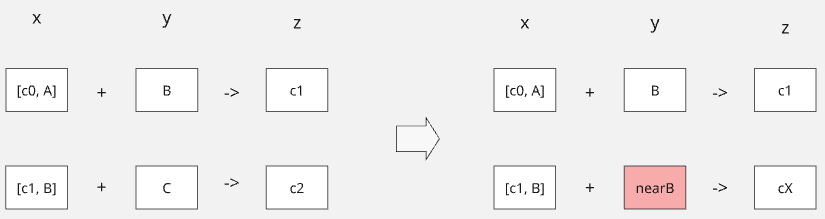

Сможем ли мы через кумулятивное расстояние Хэмминга делать дискрминацию?

In [17]:
for switch in range(1, sdr_space.p):
    near_B = sdr_space.get_near(codec('B'), switch)
    assert not sdr_space.is_overlap_equal(near_B, codec('B'))
    x = sdr_space.union(codec('B'), c_list[1])
    M1.store(x, near_B, sdr_space.get_random()) # "contaminate" memory with data near to 'B' but in different context, i.e. [c1,'B']->near_B
    
    x = sdr_space.union(codec('A'), c_list[0])
    y = near_B
    c = c_list[1]
    resolved_c = M1.query_Z(x, near_B)
    x_cleanup = M1.query_X(y, c)
    y_cleanup = M1.query_Y(x, c)
    cumulative_hdist = sdr_space.hdist(x_cleanup, x) + sdr_space.hdist(y_cleanup, y)
    print(f'Shared bits={sdr_space.p - switch}, switch bits={switch}, change={100 * switch / sdr_space.p:.0f}%, p={sdr_space.get_shared_bits_p(sdr_space.p - switch)}')
    print(f'{"B":23}{codec('B')}\n{"near_B":23}{near_B}')
    print(f'{"c_resolved":23}{resolved_c}\n{"c true":23}{true_c}')
    print(f'{"c_resolved vs c_true":23}' + 
          f'is_overlap_equal={sdr_space.is_overlap_equal(resolved_c, true_c)}, ' + 
          f'is_hdist_equal={sdr_space.is_hdist_equal(resolved_c, true_c)}, ' + 
          f'hdist={sdr_space.hdist(resolved_c, true_c)}')
    print(f'{"x_cleanup":23}{x_cleanup}\n{"x":23}{x}\n{"x_cleanup vs x":23}' + 
          f'is_overlap_equal={sdr_space.is_overlap_equal(x_cleanup, x)}, ' + 
          f'is_hdist_equal={sdr_space.is_hdist_equal(x_cleanup, x)}, ' + 
          f'hdist={sdr_space.hdist(x_cleanup, x)}')
    print(f'{"y_cleanup":23}{y_cleanup}\n{"y":23}{y}\n{"y_cleanup vs y":23}' + 
          f'is_overlap_equal={sdr_space.is_overlap_equal(y_cleanup, y)}, ' + 
          f'is_hdist_equal={sdr_space.is_hdist_equal(y_cleanup, y)}, ' + 
          f'hdist={sdr_space.hdist(y_cleanup, y)}')
    print(f'{"[x+y]_cleanup vs [x+y]":23}is_hdist_equal={cumulative_hdist <= sdr_space.p}, hdist={cumulative_hdist}\n')

Shared bits=4, switch bits=1, change=20%, p=9.700495721502335e-09
B                      [ 62 105 118 178 390]
near_B                 [105 118 178 256 390]
c_resolved             [145 164 169 332 449]
c true                 [145 164 169 332 449]
c_resolved vs c_true   is_overlap_equal=True, is_hdist_equal=True, hdist=0
x_cleanup              [ 11  73 111 138 151 206 219 250 371 466]
x                      [ 11  73 111 138 151 206 219 250 371 466]
x_cleanup vs x         is_overlap_equal=True, is_hdist_equal=True, hdist=0
y_cleanup              [ 62 105 118 178 390]
y                      [105 118 178 256 390]
y_cleanup vs y         is_overlap_equal=False, is_hdist_equal=True, hdist=2
[x+y]_cleanup vs [x+y] is_hdist_equal=True, hdist=2

Shared bits=3, switch bits=2, change=40%, p=4.799809984370463e-06
B                      [ 62 105 118 178 390]
near_B                 [ 62 118 191 363 390]
c_resolved             [145 164 169 332 449]
c true                 [145 164 169 332 449]
c_resolve

Ок. Результат такой же, как и в пункте M1.3.3. Т.е. "загрянение" памяти "не просачивается" между контекстами. Это хорошо.

### M2.1. Ещё раз про резолвинг по частичному ключу

In [18]:
a = codec(M2.query_Z(codec('A'), codec('B')))
print(f'resolved={a}')
assert a == 'C'

resolved=C


Даже без указания контекста `M2[x='A', y='B', _]` возвращает 'C'

### M2.2. Суперпозиция, когда несколько вариантов ответа

In [19]:
# добавим в M2 Z для AB, т.е. AB -> Z
M2.store(codec('A'), codec('B'), codec('Z'))
a = codec(M2.query_Z(codec('A'), codec('B')))
print(f'resolved={a}')
assert sdr_space.is_overlap_equal(codec('C'), a)
assert sdr_space.is_overlap_equal(codec('Z'), a)

resolved=[145 254 285 297 341 348 373 436 458 470]


после добавления 'Z' в `M2` последний будет возвращать суперпозицию C и Z в ответ на запрос `query_Z('A', 'B')`

### M2.3. Уточнение для сокращения вариантов ответа

In [20]:
a = codec(M2.query_Z(sdr_space.union(codec('A'), c_list[0]), codec('B')))
print(f'resolved={a}')
assert a == 'C'

resolved=C


но, если указать контекст `c_list[0]`, то `M2` будет возвращать C. То есть без дополнительной подсказки (пункт 6) возвращается всё, что знаем (суперпозиция), с подсказкой - уже конкретное

### Выводы

1) из-за комбинаторной природы TriadicMemory query запрос завершается наиболее вероятным ответом. То есть можно сказать, что практически на любой запрос будет какой-то ответ. Это контрастирует с традиционными структурами данных в программировании.
2) единственное исключение по пункту 1 - это если `x` или `y` есть новый ортогональный SDR, то `query_Z` возвращает пустоту. В принципе это логично, т.к. система встречается с совершенно новой информацией. Пункт M1.3.1. Но по ходу пьесы новых отрогональных векторов просто не останется, т.к. каждый бит будет где-то да использован в другом каком-нибудь векторе.
3) однако если `x` или `y` содержит несколько бит, которые система ранее видела, то система начинает считать, что это зашумление, а не новая информация. Пункт M1.3.2.
5) разобраться между ситуациями: а) перед нами новая информация или б) перед нами зашумлённая информация помогает novelty detection техника на базе кумулятивного расстояния Хэмминга cleanup векторов. Novely detection на базе `is_overlap_equal` не показал эффективности из-за того, что `get_near` всегда теряет биты, к которой потере `is_overlap_equal` нетолерантен. Пункт M1.3.3
6) использование контекстов позволяет разрешать неоднозначности, если у нас есть несколько путей типа `'AB'->'C'` и `'AB'->'Z'`. Т.е. контекст как бы равен подсказке, что выбрать в случае неоднозначности. Пункт M2.3
7) при этом если контекста нет, то будет возвращаться суперпозиция - пункт M2.2. Если неоднозначности нет, то суперпозиция вырождается просто в один вариант ответа
8) также поиск устойчив к шуму - пункты M1.2, M2.1
9) **однако!** Надо чётко понимать природу шума. Одно дело, когда шум - это, например, шум датчиков, когда одинакова вероятность потери/выставления битов. И другое, когда у нас превалирует суперпозиции (наложения одних сущностей на другие, что мы увидим в тесте "Ulysses"). К суперпозициями `is_hdist_equal` нетолерантен, а `is_overlap_equal` наоборот - толерантен. Зато `is_hdist_equal` толерантен к потере битов, а `is_overlap_equal` нет.

# TemporalContextMemory (R element)

In [21]:
class TemporalContextMemory():
    def __init__(self, sdr_space):
        self.ss = sdr_space
        self.mem = sdr_space.new_triadic()
        self.prev_inp = self.ss.get_empty()
        self.context = self.ss.get_empty()
        self.context_usage_stats = {}

    def flush(self):
        self.prev_inp, self.context = (self.ss.get_empty(),) * 2
        return self.context

    def __call__(self, inp):
        assert len(inp) > 0
        x = self.ss.union(self.prev_inp, self.context)
        self.context = self.mem.query_Z(x, inp)

        LOG(f'x={x}, inp={inp} -> context={self.context}')
        
        x_cleanup = self.mem.query_X(inp, self.context) # cleanup via roundtrip
        
        if not self.ss.is_overlap_equal(x_cleanup, x): # snap point! (is_overlap_equal is more relaxed than is_equal)
            self.context = self.ss.get_random()
            self.mem.store(x, inp, self.context)
            self.context_usage_stats[tuple(map(int, self.context))] = 1
            LOG(f'new context={self.context}')
        else:
            key = tuple(map(int, self.context))

            if len(key) == self.ss.p:
                assert key in self.context_usage_stats
                self.context_usage_stats[key] += 1
            else:
                is_any_updated = False
                
                for kv in filter(lambda kv: self.ss.is_overlap_equal(kv[0], key), self.context_usage_stats.items()):
                    self.context_usage_stats[kv[0]] += 1
                    is_any_updated = True

                assert is_any_updated
            
        self.prev_inp = inp
        return self.context

# Temporal Memory Test: "banana" string

## R1

In [22]:
sdr_space = SdrSpace(500, 5)
codec = Codec(sdr_space)
context_mem = TemporalContextMemory(sdr_space)
mem = sdr_space.new_triadic()
prev_inp, u, v, prediction = (sdr_space.get_empty(),) * 4

test_input = 'banana' * 5
history = ''
columns = defaultdict(list)

for inp, next_inp in zip(test_input, test_input[1:] + '$'):
    inp_orig = inp
    inp = codec(inp)
    context = context_mem(inp)

    if not sdr_space.is_equal(prediction, inp):
        mem.store(u, v, inp)

    u, v = sdr_space.union(prev_inp, context), inp
    prediction = mem.query_Z(u, v)
    prev_inp = inp
    
    columns['history'].append(history)
    columns['input'].append(inp_orig)
    columns['next_pred'].append(codec(prediction))
    columns['next_true'].append(next_inp)
    columns['is_correct_pred'].append(int(sdr_space.is_equal(codec(next_inp), prediction)))
    history = history + inp_orig

pd.DataFrame(columns)

,history,input,next_pred,next_true,is_correct_pred
0,,b,None,a,0
1,b,a,None,n,0
2,ba,n,None,a,0
3,ban,a,None,n,0
4,bana,n,a,a,1
5,banan,a,n,b,0
6,banana,b,None,a,0
7,bananab,a,n,n,1
8,bananaba,n,a,a,1
9,bananaban,a,"[8, 41, 91, 108, 121, 126, 165, 367, 394, 414]",n,0


Результаты (по колонке is_correct_pred) соответствуют тем, что в ноутбукe "Temporal Memory Elementary Algorithm.nb"

![](./img/temporal-mathematica-banana.jpg)

## R7

In [23]:
sdr_space = SdrSpace(500, 5)
codec = Codec(sdr_space)
R_list = list(map(lambda _: TemporalContextMemory(sdr_space), range(7)))
mem = sdr_space.new_triadic()
prev_inp, context, x, y, prediction = (sdr_space.get_empty(),) * 5

test_input = 'banana' * 5
history = ''
columns = defaultdict(list)

for inp, next_inp in zip(test_input, test_input[1:] + '$'):
    inp_hat = codec(inp)
    t_list = []
    
    for R in R_list:
        t = t_list[-1] if t_list else inp_hat
        t_list.append(R(t))

    if not sdr_space.is_equal(prediction, inp_hat):
        mem.store(x, y, inp_hat)

    x = sdr_space.union(t_list[0], t_list[3])
    y = sdr_space.union(t_list[1], t_list[6])
    prediction = mem.query_Z(x, y)

    columns['history'].append(history)
    columns['input'].append(inp)
    columns['next_pred'].append(codec(prediction))
    columns['next_true'].append(next_inp)
    columns['is_correct_pred'].append(int(sdr_space.is_equal(codec(next_inp), prediction)))
    history = history + inp

pd.DataFrame(columns)

,history,input,next_pred,next_true,is_correct_pred
0,,b,None,a,0
1,b,a,None,n,0
2,ba,n,None,a,0
3,ban,a,None,n,0
4,bana,n,None,a,0
5,banan,a,n,b,0
6,banana,b,None,a,0
7,bananab,a,a,n,0
8,bananaba,n,a,a,1
9,bananaban,a,"[0, 45, 90, 108, 227, 257, 295, 356, 394, 439]",n,0


Результаты (по колонке is_correct_pred) соответствуют тем, что в ноутбукe "Deep Temporal Memory - Introduction.nb"

![](./img/temporal-mathematica-banana-2.jpg)

# Temporal Memory Test: "Ulysses" text

Код основан на ноутбуке 'Temporal Memory Example - Text Learning.nb', по факту - это порт. Ключевой момент в коде - это создание контекстов для биграм. Контексты создаются при появлении новой информации. Как определить новизну? Пробуем несколько подходов:
- пустой ответ на `query_Z`
- `is_overlap_equal` для cleanup вектора `x`
- `is_hdist_equal` для cleanup векторов `concat(x,y)`
- сверка со словарём `unique_z`
- комбо: `is_overlap_equal` для cleanup вектора `x` + сверка со словарём `unique_y`

Для проверки качества novelty detection механизма будет следить за фантомными контекстами = контексты, которые определены как уже известные, но которые никогда в память не добавлялись

In [24]:
text = pathlib.Path(os.path.join('data', 'ulysses.txt')).read_text(encoding='utf-8-sig')
words = preprocess_text(text)[:50000]

In [25]:
sdr_space = SdrSpace(1000, 5)
codec = Codec(sdr_space)
MemCascade = namedtuple('MemCascade', 'serial M0 M1 M2 is_novel_z')
test_run_stats = defaultdict(list)

In [26]:
def run_temporal_memory_test(cascade, run_serial):
    cascade_serial, M0, M1, M2, is_novel_z = cascade
    prev_token, prev_bigram, prev_bigram_with_context, context, prediction = (sdr_space.get_empty(),) * 5
    hits, misses = 0, 0
    phantom_contexts_count = 0

    with LOG.auto_prefix('CASCADE', cascade_serial, 'RUN', run_serial):
        for word_ind, word in tqdm(enumerate(words), total=len(words)):
            with LOG.auto_prefix('WORDIND', word_ind, 'WORD', word):
                token = codec(word)
        
                # Bigram
                bigram = M0.query_Z(token, prev_token)
                LOG(f'token={token}, prev_token={prev_token} -> bigram={bigram}')
                prev_token_cleanup = M0.query_Y(token, bigram)
        
                if not sdr_space.is_overlap_equal(prev_token, prev_token_cleanup):
                    bigram = sdr_space.get_random()
                    M0.store(token, prev_token, bigram)
                    LOG(f'new bigram={bigram}')
        
                # Context
                x = sdr_space.union(prev_bigram, context)
                context = M1.query_Z(x, bigram)
                LOG(f'x={x}, bigram={bigram} -> context={context}')
                
                if is_novel_z(M1, x, bigram, context):
                    context = sdr_space.get_random()
                    M1.store(x, bigram, context)
                    LOG(f'new context={context}')
                else:
                    key = tuple(map(int, context))
    
                    if len(key) == sdr_space.p:
                        if key in M1.unique_z:
                            M1.unique_z[key] += 1
                        else:
                            LOG(f'WARNING_1! phantom context {context}')
                            phantom_contexts_count += 1
                    else:
                        is_any_updated = False
                        
                        for kv in filter(lambda kv: sdr_space.is_overlap_equal(kv[0], key), M1.unique_z.items()):
                            M1.unique_z[kv[0]] += 1
                            is_any_updated = True
    
                        if not is_any_updated:
                            LOG(f'WARNING_2! phantom context {context}')
                            phantom_contexts_count += 1
        
                # Prediction
                if not sdr_space.is_equal(prediction, token): # is_equal, not is_overlap_equal!!!
                    M2.store(prev_bigram_with_context, prev_bigram, token)
                    misses += 1
                else:
                    hits += 1
            
                prediction = M2.query_Z(x, bigram)
                prev_token = token
                prev_bigram = bigram
                prev_bigram_with_context = x
        
        print(f'{hits / (hits + misses):.4f}, hits={hits}, misses={misses}')
        return hits, misses, phantom_contexts_count

In [27]:
def run_termporal_test_n_times_with_tracking(cascade, runs_count):
    assert runs_count > 0
    cascade_serial, M0, M1, M2, _ = cascade
    
    for run_serial in range(runs_count):
        start_time = time.time()
        hits, misses, phantom_contexts_count = run_temporal_memory_test(cascade, run_serial)
        end_time = time.time()
        execution_time = end_time - start_time
        test_run_stats['cascade'].append(cascade_serial)
        test_run_stats['run'].append(run_serial)
        test_run_stats['dur'].append(execution_time)
        test_run_stats['hits'].append(hits)
        test_run_stats['misses'].append(misses)
        test_run_stats['accuracy'].append(hits / (hits + misses))
        test_run_stats['phantoms'].append(phantom_contexts_count)
        test_run_stats['M0.stores'].append(M0.stores)
        test_run_stats['M1.stores'].append(M1.stores)
        test_run_stats['M2.stores'].append(M2.stores)
        test_run_stats['|M0.unique_x|'].append(len(M0.unique_x))
        test_run_stats['|M1.unique_x|'].append(len(M1.unique_x))
        test_run_stats['|M2.unique_x|'].append(len(M2.unique_x))
        test_run_stats['|M0.unique_y|'].append(len(M0.unique_y))
        test_run_stats['|M1.unique_y|'].append(len(M1.unique_y))
        test_run_stats['|M2.unique_y|'].append(len(M2.unique_y))
        test_run_stats['|M0.unique_z|'].append(len(M0.unique_z))
        test_run_stats['|M1.unique_z|'].append(len(M1.unique_z))
        test_run_stats['|M2.unique_z|'].append(len(M2.unique_z))
        test_run_stats['top_3(M0.unique_x)'].append(Counter(M0.unique_x).most_common(3))
        test_run_stats['top_3(M1.unique_x)'].append(Counter(M1.unique_x).most_common(3))
        test_run_stats['top_3(M2.unique_x)'].append(Counter(M2.unique_x).most_common(3))
        test_run_stats['top_3(M0.unique_y)'].append(Counter(M0.unique_y).most_common(3))
        test_run_stats['top_3(M1.unique_y)'].append(Counter(M1.unique_y).most_common(3))
        test_run_stats['top_3(M2.unique_y)'].append(Counter(M2.unique_y).most_common(3))
        test_run_stats['top_3(M0.unique_z)'].append(Counter(M0.unique_z).most_common(3))
        test_run_stats['top_3(M1.unique_z)'].append(Counter(M1.unique_z).most_common(3))
        test_run_stats['top_3(M2.unique_z)'].append(Counter(M2.unique_z).most_common(3))

## cascade0: novelty via empty z

In [28]:
def is_novel_z_empty_z(M, x, y, z):
    return len(z) == 0

cascade0 = MemCascade(
    serial=0,
    M0=sdr_space.new_triadic(), # bigrams
    M1=sdr_space.new_triadic(), # contexts
    M2=sdr_space.new_triadic(), # predictions
    is_novel_z=is_novel_z_empty_z,
)

In [29]:
run_termporal_test_n_times_with_tracking(cascade0, 4)

  0%|          | 0/50000 [00:00<?, ?it/s]

0.0231, hits=1156, misses=48844


  0%|          | 0/50000 [00:00<?, ?it/s]

0.7564, hits=37818, misses=12182


  0%|          | 0/50000 [00:00<?, ?it/s]

0.8660, hits=43299, misses=6701


  0%|          | 0/50000 [00:00<?, ?it/s]

0.9428, hits=47141, misses=2859


## cascade1: novelty via is_overlap_equal

In [30]:
def is_novel_z_is_overlap_equal_on_x(M, x, y, z):
    x_cleanup = M.query_X(y, z)
    return not sdr_space.is_overlap_equal(x, x_cleanup)

cascade1 = MemCascade(
    serial=1,
    M0=sdr_space.new_triadic(), # bigrams
    M1=sdr_space.new_triadic(), # contexts
    M2=sdr_space.new_triadic(), # predictions
    is_novel_z=is_novel_z_is_overlap_equal_on_x,
)

In [31]:
run_termporal_test_n_times_with_tracking(cascade1, 4)

  0%|          | 0/50000 [00:00<?, ?it/s]

0.0218, hits=1092, misses=48908


  0%|          | 0/50000 [00:00<?, ?it/s]

0.9126, hits=45629, misses=4371


  0%|          | 0/50000 [00:00<?, ?it/s]

0.9680, hits=48400, misses=1600


  0%|          | 0/50000 [00:00<?, ?it/s]

0.9775, hits=48877, misses=1123


## cascade2: novelty via is_hdist_equal

In [32]:
def is_novel_z_cum_hdist_on_xy(M, x, y, z):
    x_cleanup = M.query_X(y, z)
    y_cleanup = M.query_Y(x, z)
    cumulative_hdist = sdr_space.hdist(x_cleanup, x) + sdr_space.hdist(y_cleanup, y)
    return cumulative_hdist > sdr_space.p

cascade2 = MemCascade(
    serial=2,
    M0=sdr_space.new_triadic(), # bigrams
    M1=sdr_space.new_triadic(), # contexts
    M2=sdr_space.new_triadic(), # predictions
    is_novel_z=is_novel_z_cum_hdist_on_xy,
)

In [33]:
run_termporal_test_n_times_with_tracking(cascade2, 4)

  0%|          | 0/50000 [00:00<?, ?it/s]

0.0205, hits=1023, misses=48977


  0%|          | 0/50000 [00:00<?, ?it/s]

0.8531, hits=42654, misses=7346


  0%|          | 0/50000 [00:00<?, ?it/s]

0.9333, hits=46665, misses=3335


  0%|          | 0/50000 [00:00<?, ?it/s]

0.9399, hits=46994, misses=3006


## cascade3: novelty via lookup into unique_z

In [35]:
def is_novel_z_lookup_into_unique_z(M, x, y, z):
    key = tuple(map(int, z))
    return not key in M.unique_z

cascade3 = MemCascade(
    serial=3,
    M0=sdr_space.new_triadic(), # bigrams
    M1=sdr_space.new_triadic(), # contexts
    M2=sdr_space.new_triadic(), # predictions
    is_novel_z=is_novel_z_lookup_into_unique_z,
)

In [36]:
run_termporal_test_n_times_with_tracking(cascade3, 4)

  0%|          | 0/50000 [00:00<?, ?it/s]

0.0203, hits=1016, misses=48984


  0%|          | 0/50000 [00:00<?, ?it/s]

0.9064, hits=45319, misses=4681


  0%|          | 0/50000 [00:00<?, ?it/s]

0.9682, hits=48410, misses=1590


  0%|          | 0/50000 [00:00<?, ?it/s]

0.9762, hits=48812, misses=1188


## cascade4: novelty via (is_overlap_equal | lookup into unique_y)

In [37]:
def is_novel_z_is_overlap_equal_or_lookup_into_unique_y(M, x, y, z):
    x_cleanup = M.query_X(y, z)
    yk = tuple(map(int, y))
    return not sdr_space.is_overlap_equal(x, x_cleanup) or not yk in M.unique_y

cascade4 = MemCascade(
    serial=4,
    M0=sdr_space.new_triadic(), # bigrams
    M1=sdr_space.new_triadic(), # contexts
    M2=sdr_space.new_triadic(), # predictions
    is_novel_z=is_novel_z_is_overlap_equal_or_lookup_into_unique_y,
)

In [38]:
run_termporal_test_n_times_with_tracking(cascade4, 4)

  0%|          | 0/50000 [00:00<?, ?it/s]

0.0206, hits=1032, misses=48968


  0%|          | 0/50000 [00:00<?, ?it/s]

0.9124, hits=45619, misses=4381


  0%|          | 0/50000 [00:00<?, ?it/s]

0.9675, hits=48373, misses=1627


  0%|          | 0/50000 [00:00<?, ?it/s]

0.9781, hits=48904, misses=1096


## Что по фантомным контекстам

In [41]:
df = pd.DataFrame(test_run_stats)
df[['cascade', 'run', 'hits', 'misses', 'accuracy', 'phantoms', 'M0.stores',  'M1.stores', 'M2.stores']]

,cascade,run,hits,misses,accuracy,phantoms,M0.stores,M1.stores,M2.stores
0,0,0,1156,48844,0.02312,217,28208,1458,48844
1,0,1,37818,12182,0.75636,453,28814,1580,61026
2,0,2,43299,6701,0.86598,514,28833,1616,67727
3,0,3,47141,2859,0.94282,537,28834,1623,70586
4,1,0,1092,48908,0.02184,2207,28200,42939,48908
5,1,1,45629,4371,0.91258,1622,28817,50853,53279
6,1,2,48400,1600,0.96800,1476,28836,52587,54879
7,1,3,48877,1123,0.97754,1464,28837,52947,56002
8,2,0,1023,48977,0.02046,268,28209,49197,48977
9,2,1,42654,7346,0.85308,2012,28825,93859,56323


![](./img/phantom-contexts.jpg)

Тестовые прогоны были выполнены для двух различных реализация функции `TriadicMemory.store`: когда счётчик адресов инкрементировался и когда просто выставлялся в 1. Первый способ - это ванильная реализация TriadicMemory (в статье и в Mathematica ноутбуках), второй способ - это Си-шная реализация.

Сразу можно заметить, что accuracy первого варианта ниже, чем второго. Пока непонятно почему так получается. Концептуально инкремент счётчика должен давать более верный результат что-ли, т.к. корректнее отражает суперпозиционную логику (когда могут наслаиваться несколько сущностей). *Отдельная тема для исследования, короче.*

Если говорить про фантомные контексты, то их неожиданно очень много в cascade2. Хотя казалось бы проверка на новизну там более сильная и ванильная (описана в исходной статье). Пришёл к выводу, что причина в большом количестве суперпозиций. В логах можно видеть, что входящие x/y могут достигать аж 70 битов. А как было выяснено `is_hdist_equal` нетолерантен к суперпозициям. Поэтому в cascade2 плодится больше всех контекстов (см. M1.stores). Т.е. почему контекстов много - понятно. Непонятно, почему фантомных много. Сначала подумал, что дело в том, что проверка на фантомность делается через `is_overlap_equal`, а не через `is_hdist_equal`. Но замена на `is_hdist_equal` не дала никакого эффекта. Дальнеёшее ковыряние не стал проводтиь.

cascade0 ожидаемо немного контекстов плодит (экономный). Также ожидаемо, что cascade3 не страдает от фантомных контекстов, т.к. всегда сверяется со словарём unique_z (что в биологической реализации неправдоподобно). Сбалансировано выглядит cascade4, но он также биологически неправдоподобен (не может же наш мозг поддерживать точные словари, как в питоне).

Получается, что cascade1 самый сбалансированный по комбинации скорость+точность+нагрузка на память+биологическая правдоподбность.

## autopredict

Даём системе промпт (несколько слов из оригинального текста) и потом замыкаем вывод системы на вход. Получается, что система продолжает свой же разговор (разговаривает сама с собой). Смотрим, что в итоге сгенерировалось - равно ли оно тому, что было в оригинальном тексте.

In [42]:
def autopredict(cascade, prompt, count=20, is_readonly=True):
    _, M0, M1, M2, is_novel_z = cascade
    prev_token, prev_bigram, prev_bigram_with_context, context, prediction = (sdr_space.get_empty(),) * 5
    result = []
    
    for word in prompt + [None] * count:
        if word is None:
            # Prompt is over, now let's see what system generates in response to consumed prompt
            token = prediction
    
            if len(token) > sdr_space.p:
                for sdr, s in codec.sdr_to_str.items():
                    if sdr_space.overlap(sdr, token) == sdr_space.p:
                        word = s
                        token = sdr
                        break
            else:
                word = codec(token)

            result.append(word)
        else:
            token = codec(word)
            
        # Bigram
        bigram = M0.query_Z(token, prev_token)
        prev_token_cleanup = M0.query_Y(token, bigram)

        if not is_readonly and not sdr_space.is_overlap_equal(prev_token, prev_token_cleanup):
            bigram = sdr_space.get_random()
            M0.store(token, prev_token, bigram)
    
        # Context
        x = sdr_space.union(prev_bigram, context)
        context = M1.query_Z(x, bigram)

        if not is_readonly and is_novel_z(M1, x, bigram, context):
            context = sdr_space.get_random()
            M1.store(x, bigram, context)
    
        # Prediction
        prediction = M2.query_Z(x, bigram)
        
        prev_token = token
        prev_bigram = bigram
        prev_bigram_with_context = x

    return result

In [55]:
prompt_len = 20
words_to_predict = 20
start_pos_list = RNG.choice(len(words) - prompt_len - words_to_predict, 5)
prompts = []
afterprompts = []

for start_pos in start_pos_list:
    prompt = words[start_pos:start_pos+prompt_len]
    afterprompt = words[start_pos+prompt_len:start_pos+prompt_len+words_to_predict]
    prompts.append(prompt)
    afterprompts.append(afterprompt)

prompts.append(preprocess_text('Hello. How are you? Would you like to go to the bar tonight?'))
afterprompts.append('')

for prompt, afterprompt in zip(prompts, afterprompts):
    print(f'{"Prompt:":20} {" ".join(prompt)}')
    print(f'{"Afterprompt:":20} {" ".join(afterprompt)}')
    
    for cascade in [cascade0, cascade1, cascade2, cascade3, cascade4]:
        predicted = autopredict(cascade, prompt, words_to_predict)
        cascade_name = f'Cascade {cascade.serial}:'
        predicted_str = ' '.join(map(str, predicted))
        print(f'{cascade_name:20} {predicted_str}')

    print('')

Prompt:              Rather stale smell that incense leaves next day Like foul flowerwater Would you like the window open a little She
Afterprompt:         doubled a slice of bread into her mouth asking What time is the funeral Eleven I think he answered I
Cascade 0:           doubled a slice of bread into her mouth asking What time is the funeral Eleven I think he answered I
Cascade 1:           doubled a slice of bread into her mouth asking What time is the funeral None I think he answered I
Cascade 2:           doubled a slice of the loaf He shore away the burnt flesh and flung it to the cat Then he
Cascade 3:           doubled a slice of bread into her mouth asking What time is the funeral [198 347 436 579 582] I think he answered I
Cascade 4:           doubled a slice of bread into her mouth asking What time is the funeral Eleven Thumping Thump This morning the

Prompt:              was not afraid The melon he had he held against my face Smiled creamfruit smell That was the rule s

In [53]:
prompt_len = 20
words_to_predict = 20
scoreboard = defaultdict(list)
start_pos_list = RNG.choice(len(words) - prompt_len - words_to_predict, 1000)
    
for start_pos in tqdm(start_pos_list):
    prompt = words[start_pos:start_pos+prompt_len]
    afterprompt = words[start_pos+prompt_len:start_pos+prompt_len+words_to_predict]
    prompt_str = ' '.join(prompt)
    afterprompt_str = ' '.join(afterprompt)
    
    for cascade in [cascade0, cascade1, cascade2, cascade3, cascade4]:
        predicted = autopredict(cascade, prompt, words_to_predict)
        cascade_name = f'Cascade {cascade.serial}'
        predicted_str = ' '.join(map(str, predicted))
        scoreboard['cascade'].append(cascade_name)
        scoreboard['prompt'].append(prompt_str)
        scoreboard['afterprompt'].append(afterprompt_str)
        scoreboard['predicted'].append(predicted_str)
        scoreboard['is_correct'].append(predicted_str == afterprompt_str)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [54]:
df = pd.DataFrame(scoreboard)
df_pivot = pd.pivot_table(df, index='cascade', columns=['is_correct'], values=['predicted'], aggfunc=['count'])
df_pivot['accuracy'] = df_pivot[('count', 'predicted', True)] / (df_pivot[('count', 'predicted', False)] + df_pivot[('count', 'predicted', True)])
df_pivot

count      accuracy
           predicted              
is_correct     False True         
cascade                           
Cascade 0        247  753    0.753
Cascade 1        195  805    0.805
Cascade 2        316  684    0.684
Cascade 3        221  779    0.779
Cascade 4        192  808    0.808

По точности автопредсказания на первом месте cascade4 (80,8% точно воспроизведенных отрвыков), на втором с небольшим отставанием cascade1 (80,5%). cascade2 - самый тухлый.

## Выводы

1) Если смотреть в целом на статы по фантомным контекстам и точности автопредсказания, то cascade1 действительно выглядит самым сбалансированным. Ставка на cascade2 не оправдалась. Даже тупой cascade0 делает cascade2 в одну калитку.
2) в процессе возни/борьбы с фантомными контекстами пришла мысль. А быть может и не надо с ними бороться совсем. Ведь на это являение можно смотреть следующим образом. Вот у нас идёт поток токенов, мы из них делаем биграммы, потом контекстуально через `M1` соединяем. По мере эволюции системы будут появляться суперпозиции, делающие контекстуальность всё более расплывчатой (т.е. то ли это контекст А, то ли Б, то ли В). Вот эту неопределенность и сопровождают фантомы - контексты, которых мы никогда не создавали (`M1.unique_z`). Изначально стремление было, чтобы создание контекстов было точной процедурой (как в традиционном программировании. Т.е. пришли новые данные - делаем новый контекст, известные - используем старый). Однако сдаётся, что контексты `M1` должны лишь обеспечивать этакое мягкое разделение потока данных. Можно сказать, обеспечивать пропагирование дальше каких-то веяний дальше к `M2`. И они и не должны чётко и однозначно разделять. Если бы мы добились чёткого и однозначного разбиения, то кол-во контекстов было бы огромно (см. cascade2), и о генерализации можно было бы забыть. То есть мы изначально согласны, что контекст неоднозначно описывает поток данных, но лишь определяет этакое распределение вероятности. И тогда, когда управление доходит к `M2`, то тот берёт текущее слово, предыдущее и контекст (распределение вероятности), и уже на этой троице предсказывает следующее слово. **Распределение вероятности - вот скорее всего какая роль у контекстов `M1`**. И мы создаём новый контекст только тогда, когда это распределение становится слишком широким и аморфным (что в некотоое степени объясняет, почему `is_overlap_equal` по cleanup `x` работет. Типа когда настолько непонятная ситуация, что по контексту не удаётся разглядет исходные данные).
3) всё это в высшей степени напоминает reservoir computing [VrugtIntroReservComp]. У нас есть резервуар - комбо из `M0` и `M1`. Через резервуар последовательно проходят данные, резервуар реагирует формированием контекстов. И дальше уже подключается `M2`, который благодаря `is_equal` выполняет роль feed-forward neural net (FNN), которая уже тренится. В таком сетапе нам действительно не требуется, чтобы выхлоп резервуара был супер-пупер точным - всегло лишь требуется, чтобы было мягкое разделение данных по стримам, которое разделение уже подхватит `M2`

# Consume and generate

In [30]:
assert False

AssertionError: 

In [19]:
text = pathlib.Path('ulysses.txt').read_text(encoding='utf-8-sig')
words = preprocess_text(text)[:50000]

## Bigrams

In [246]:
sdr_space = SdrSpace(1000, 5)
codec = Codec(sdr_space)

In [247]:
M0 = sdr_space.new_triadic()
M1 = sdr_space.new_triadic()
M2 = sdr_space.new_triadic()

In [248]:
prev_token, prev_bigram, prev_bigram_with_context, context, prediction = (sdr_space.get_empty(),) * 5
i, j, y, c, u, v, prediction = (sdr_space.get_empty(),) * 7

for run in range(4):
    hits, misses = 0, 0
    
    for word_ind, word in tqdm(enumerate(words), total=len(words)):
        token = codec(word)

        if False:
            j = i
            i = token
            bigram = M0.query_Z(i, j)

            if not sdr_space.is_overlap_equal(M0.query_Y(i, bigram), j):
                bigram = sdr_space.get_random()
                M0.store(i, j, bigram)

            x = sdr_space.union(y, c)
            y = bigram

            c = M1.query_Z(x, y)

            if not sdr_space.is_overlap_equal(M1.query_X(y, c), x):
                c = sdr_space.get_random()
                M1.store(x, y, c)

            if not sdr_space.is_equal(prediction, i): # is_equal, not is_overlap_equal!!!
                M2.store(u, v, i)
                misses += 1
            else:
                hits += 1

            u = x
            v = y
            prediction = M2.query_Z(u, v)
        else:
            # Bigram
            bigram = M0.query_Z(token, prev_token)
            prev_token_cleanup = M0.query_Y(token, bigram)
    
            if not sdr_space.is_overlap_equal(prev_token, prev_token_cleanup):
                bigram = sdr_space.get_random()
                M0.store(token, prev_token, bigram)
    
            # Context
            x = sdr_space.union(prev_bigram, context)
            context = M1.query_Z(x, bigram)
            x_cleanup = M1.query_X(bigram, context)
    
            if not sdr_space.is_overlap_equal(x, x_cleanup):
                context = sdr_space.get_random()
                M1.store(x, bigram, context)
    
            # Prediction
            if not sdr_space.is_equal(prediction, token): # is_equal, not is_overlap_equal!!!
                M2.store(prev_bigram_with_context, prev_bigram, token)
                misses += 1
            else:
                hits += 1
        
            prediction = M2.query_Z(x, bigram)
            prev_token = token
            prev_bigram = bigram
            prev_bigram_with_context = x
    
    print(f'{hits / (hits + misses):.4f}, hits={hits}, misses={misses}')

  0%|          | 0/50000 [00:00<?, ?it/s]

0.0194, hits=972, misses=49028


  0%|          | 0/50000 [00:00<?, ?it/s]

0.9253, hits=46265, misses=3735


  0%|          | 0/50000 [00:00<?, ?it/s]

0.9809, hits=49045, misses=955


  0%|          | 0/50000 [00:00<?, ?it/s]

0.9858, hits=49289, misses=711


In [254]:
# prompt = preprocess_text("London is a captial of great britain")
# prompt = preprocess_text("I would like to go to the bar")
prompt = words[0:50]
prev_token, prev_bigram, prev_bigram_with_context, context, prediction = (sdr_space.get_empty(),) * 5

for word in prompt + [None] * 20:
    if word is None:
        # Prompt is over, now let's see what system generates in response to consumed prompt
        token = prediction

        if len(token) > sdr_space.p:
            for sdr, s in codec.sdr_to_str.items():
                if sdr_space.overlap(sdr, token) == sdr_space.p:
                    word = s
                    token = sdr
                    break
        else:
            word = codec(token)
        
        print(" ", word)
    else:
        print("*", word)
        token = codec(word)
        
    # Bigram
    bigram = M0.query_Z(token, prev_token)
    prev_token_cleanup = M0.query_Y(token, bigram)

    if not sdr_space.is_overlap_equal(prev_token, prev_token_cleanup):
        bigram = sdr_space.get_random()
        M0.store(token, prev_token, bigram)

    # Context
    x = sdr_space.union(prev_bigram, context)
    context = M1.query_Z(x, bigram)
    x_cleanup = M1.query_X(bigram, context)

    if not sdr_space.is_overlap_equal(x, x_cleanup):
        context = sdr_space.get_random()
        M1.store(x, bigram, context)

    # Prediction
    prediction = M2.query_Z(x, bigram)
    
    prev_token = token
    prev_bigram = bigram
    prev_bigram_with_context = x

* The
* Project
* Gutenberg
* eBook
* of
* Ulysses
* This
* ebook
* is
* for
* the
* use
* of
* anyone
* anywhere
* in
* the
* United
* States
* and
* most
* other
* parts
* of
* the
* world
* at
* no
* cost
* and
* with
* almost
* no
* restrictions
* whatsoever
* You
* may
* copy
* it
* give
* it
* away
* or
* re-use
* it
* under
* the
* terms
* of
* the
  Project
  Gutenberg
  License
  included
  with
  this
  ebook
  or
  online
  at
  www.gutenberg.org
  If
  you
  are
  not
  located
  in
  the
  United
  States


## R7

In [31]:
sdr_space = SdrSpace(1000, 5)
codec = Codec(sdr_space)

In [32]:
R_list = list(map(lambda _: TemporalContextMemory(sdr_space), range(7)))
mem = sdr_space.new_triadic()

In [104]:
x = np.asmatrix('4  10  20  32  53 112 122 146 149 173 180 193 223 232 270 307 309 311 326 342 354 355 357 361 406 435 475 488 493 513 541 545 559 578 580 620 645 646 666 677 678 681 685 705 713 714 715 724 728 732 776 810 811 813 814 824 830 831 866 881 907 909 938 952 955 960 972 989 997 998')
x = np.array(x).ravel()
# R_list[1].mem.query_Z(x, np.array([84, 127, 276, 410, 963]))
R_list[1].mem.query_Z(x, np.array([85, 127, 276, 411, 963]))

array([114, 152, 486, 525, 672, 840, 914, 967, 970])

array([486, 834, 840, 914, 970])

In [53]:
c = R_list[1].mem.query_X(np.array([84, 127, 276, 410, 963]), np.array([486, 834, 840, 914, 970]))
c

array([  2,  10,  13,  28,  34,  73,  87, 120, 142, 161, 176, 186, 217,
       219, 221, 254, 318, 335, 364, 389, 418, 431, 472, 481, 517, 535,
       556, 573, 585, 588, 613, 624, 641, 650, 663, 675, 677, 684, 701,
       712, 733, 744, 774, 775, 802, 813, 831, 861, 871, 933, 998])

In [55]:
x = np.asmatrix('4  10  20  32  53 112 122 146 149 173 180 193 223 232 270 307 309 311 326 342 354 355 357 361 406 435 475 488 493 513 541 545 559 578 580 620 645 646 666 677 678 681 685 705 713 714 715 724 728 732 776 810 811 813 814 824 830 831 866 881 907 909 938 952 955 960 972 989 997 998')
x = np.array(x).ravel()
set(x) & set(c)

{np.int64(10), np.int64(677), np.int64(813), np.int64(831), np.int64(998)}

In [56]:
len(R_list[1].context_usage_stats)

2569

In [101]:
# 84
qqq = []
qqq.append('''
84 211 316 616 918
84 402 406 516 798
8  14  17  84 106 121 132 135 181 188 357 402 406 500 516 562 569 644 672 728 759 798 841 888
84 110 356 462 639
2  84 211 316 388 410 429 616 847 918''')

# 127
qqq.append('''
37 127 320 414 825
82 127 707 836 941
32  76 127 508 665''')

# 276
qqq.append('''
36 143 222 276 609
223 276 707 923 943
3 170 276 369 564
20 276 563 719 827
260 276 481 634 850
228 276 309 650 996
73 276 488 644 926
55 103 164 223 262 276 440 443 473 494 502 539 567 597 609 707 731 736 755 881 923 931 943 948 982
73 230 276 287 322 346 425 486 488 588 644 717 926 937 941''')

# 410
qqq.append('''
340 410 504 884 952
152 193 313 410 586
116 309 410 424 624
0  68 152 168 193 195 222 271 307 313 410 424 445 512 523 544 586 640 643 672 755 788 789 902 955
356 410 553 640 821
199 410 610 614 641
244 327 410 440 725
356 410 553 640 821
320 410 537 661 716
232 337 410 763 952
108 259 410 669 843
24  37  40  59  91 132 152 159 193 221 313 318 330 364 410 503 510 547 586 592 624 777 813 862 999
199 410 610 614 641
210 401 410 533 614
2 388 410 429 847
2  84 211 316 388 410 429 616 847 918
340 410 504 884 952''')

# 963
qqq.append('''
320 432 497 765 963
87 430 473 963 986
351 471 505 810 963
676 916 925 963 974
191 375 680 898 963
139 328 795 963 979
12  62  87 115 240 258 376 430 441 453 473 482 498 537 554 559 593 609 686 699 708 731 944 963 986
110 297 472 907 963
292 293 413 494 963
597 773 938 963 999
31 243 423 963 986
654 772 805 959 963
292 293 413 494 963
2  45  65  78  81  87 128 138 154 248 250 294 406 430 463 473 508 576 609 616 726 729 782 799 856 876 963 970 974 986
274 302 810 943 963
0 399 674 809 963''')

q_gold = set([84, 127, 276, 410, 963])

for qq in qqq:
    qq = qq.strip()
    
    for q in qq.split(sep='\n'):
        q = set(map(int, q.split()))
        overlap = len(q & q_gold)

        if overlap >= 2:
            print(f'overlap={overlap}, {sorted(q)}')           
        

overlap=2, [2, 84, 211, 316, 388, 410, 429, 616, 847, 918]
overlap=2, [2, 84, 211, 316, 388, 410, 429, 616, 847, 918]


In [68]:
k = tuple(map(int, np.array([486, 834, 840, 914, 970])))
k_ = set(k)

for xk in R_list[1].context_usage_stats.keys():
    xk_ = set(xk)
    
    if len(k_ & xk_) >= 2:
        print(sorted(xk_))

[312, 670, 840, 914, 979]
[195, 525, 668, 914, 970]
[26, 486, 549, 589, 970]
[361, 477, 486, 686, 834]


In [33]:
x, y, prediction = (sdr_space.get_empty(),) * 3

for run in range(4):
    hits, misses = 0, 0
    
    for word_ind, word in tqdm(enumerate(words), total=len(words)):
        with LOG.auto_prefix('WORDIND', word_ind, 'WORD', word):
            token = codec(word)
            LOG(f'token={token}')
            
            t_list = []
            
            for R_ind, R in enumerate(R_list):
                with LOG.auto_prefix('R', R_ind):
                    t = t_list[-1] if t_list else token
                    t_list.append(R(t))
    
            if not sdr_space.is_equal(prediction, token):
                mem.store(x, y, token)
                misses += 1
            else:
                hits += 1
        
            x = sdr_space.union(t_list[0], t_list[3])
            y = sdr_space.union(t_list[1], t_list[6])
            prediction = mem.query_Z(x, y)

    print(f'{hits / (hits + misses):.4f}, hits={hits}, misses={misses}')

  0%|          | 0/50000 [00:00<?, ?it/s]

AssertionError: 

In [42]:
# prompt = preprocess_text("London is a captial of great britain")
prompt = preprocess_text("Where would you like to go tonight?")
# prompt = preprocess_text("Rusty key scraped round harshly twice and, when the heavy door had been")
# prompt = words[:50]
x, y = (my_empty_sdr(),) * 2

for word in prompt + [None] * 20:
    if word is None:
        # Prompt is over, now let's see what system generates in response to consumed prompt
        token = mem.query_Z(x, y)
        word = codec(token)

        if len(token) > P:
            for sdr, s in codec_cache.sdr_to_str.items():
                if my_sdr_overlap(sdr, token) == P:
                    word = s
                    token = sdr
                    break
        
        print(" ", token, word)
    else:
        token = codec(word)
        print("*", token, word)
        
    t_list = []
    
    for R in R_list:
        t = t_list[-1] if t_list else token
        t_list.append(R(t))

    x = my_sdr_union(t_list[0], t_list[3])
    y = my_sdr_union(t_list[1], t_list[6])

# for _ in range(20):
#     token = mem.query_Z(x, y)
#     print(codec(token))

#     t_list = []
    
#     for R in R_list:
#         t = t_list[-1] if t_list else token
#         t_list.append(R(t))

#     x = my_sdr_union(t_list[0], t_list[3])
#     y = my_sdr_union(t_list[1], t_list[6])    

* [ 44  51 312 333 489] Where
* [ 31 217 392 420 438] would
* [ 55 123 180 426 476] you
* [150 168 265 270 428] like
* [ 13  80 304 447 478] to
* [ 84 161 383 395 404] go
* [181 250 319 322 385] tonight
  [ 41  94 147 162 202] [ 41  94 147 162 202]
  [ 41  94 147 162 202] [ 41  94 147 162 202]
  [ 41  94 147 162 424 436] [ 41  94 147 162 424 436]
  [ 41  94 147 202 436] [ 41  94 147 202 436]
  [ 41  94 147 162 436] [ 41  94 147 162 436]
  [ 41  94 147 162 424 436] [ 41  94 147 162 424 436]
  [ 41 147 194 321 436] [ 41 147 194 321 436]
  [ 41 138 147 217 436] [ 41 138 147 217 436]
  [ 41  94 147 162 202] [ 41  94 147 162 202]
  [ 41  94 147 162 202] [ 41  94 147 162 202]
  [ 41  94 147 217 436] [ 41  94 147 217 436]
  [ 41  94 147 162 202] [ 41  94 147 162 202]
  [ 41  94 147 162 202 436] [ 41  94 147 162 202 436]
  [ 41  94 147 162 436] [ 41  94 147 162 436]
  [ 41 147 162 202 373] [ 41 147 162 202 373]
  [ 41  94 147 162 436] [ 41  94 147 162 436]
  [ 41  94 147 162 436] [ 41  94 147 